<a href="https://colab.research.google.com/github/userskins/dsp-seminars-gusev-da/blob/Lab2/seminars/2_%D0%93%D1%83%D1%81%D0%B5%D0%B2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Практическое задание №2
## Амплитудная и фазовая модуляция: генерация, спектры, демодуляция и устойчивость к шумам

**Цель работы:**
- Научиться генерировать сигналы с амплитудной (АМ) и фазовой (ФМ) модуляцией.
- Исследовать спектральные характеристики модулированных сигналов.
- Изучить влияние индекса модуляции на спектр ФМ сигнала.
- Освоить демодуляцию АМ и ФМ с помощью преобразования Гильберта.
- Оценить устойчивость АМ и ФМ к амплитудному шуму на примере реального аудиосигнала.

**Необходимое ПО:** Python 3, библиотеки `numpy`, `matplotlib`, `scipy`, `ipywidgets`, `IPython.display`. Работа выполняется в Jupyter Notebook / Google Colab.

**Формат сдачи:** один Jupyter Notebook с кодом, графиками и текстовыми выводами. Имя файла: `2_Фамилия.ipynb`.

## Часть 1. Генерация и визуализация модулированных сигналов

### 1.1. Импорт библиотек и параметры

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.io import wavfile
from scipy.signal import hilbert
import ipywidgets as widgets
from IPython.display import Audio, display

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 5)

# Параметры дискретизации для демонстрации
fs = 10000                     # частота дискретизации (Гц)
T = 0.1                        # длительность сигнала (с)
t = np.linspace(0, T, int(fs*T), endpoint=False)

# Несущая
fc = 1000                      # частота несущей (Гц)
Ac = 1.0                       # амплитуда несущей

### 1.2. Модулирующий сигнал

В качестве модулирующего сигнала используйте сумму двух синусоид с частотами 100 Гц и 150 Гц, нормализованную к диапазону [-1, 1]. Постройте его график.

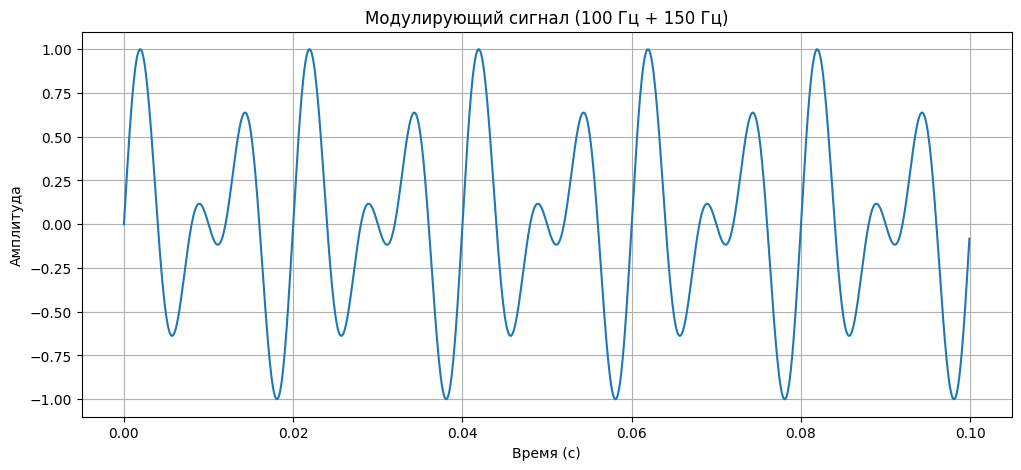

In [4]:
fm1 = 100
fm2 = 150
m_t = np.sin(2 * np.pi * fm1 * t) + np.sin(2 * np.pi * fm2 * t)
m_t = m_t / np.max(np.abs(m_t)) # модулирующий сигнал - сумма двух синусоид со значениями в интервале [-1,1]

plt.figure()
plt.plot(t, m_t)
plt.title('Модулирующий сигнал (100 Гц + 150 Гц)')
plt.xlabel('Время (с)')
plt.ylabel('Амплитуда')
plt.grid(True)
plt.show()

### 1.3. Амплитудная модуляция (АМ)

Формула АМ:
$$s_{AM}(t) = A_c [1 + a_{AM}\cdot m(t)] \cos(2\pi f_c t)
$$
Параметр $a_{AM}$ регулирует _глубину модуляции_, он не может быть больше 1 (при $a_{AM}>1$ и исходном сигнале $m(t)$, нормализованном на единицу, амплитуда результирующего сигнала в некоторые промежутки времени становится отрицательной).

In [5]:
a_am = 0.2
s_am = Ac * (1 + a_am * m_t) * np.cos(2 * np.pi * fc * t)

### 1.4. Фазовая модуляция (ФМ)

Формула ФМ:
$$
s_{PM}(t) = A_c \cos(2\pi f_c t + \beta \cdot m(t)),
$$

где $\beta$ – индекс фазовой модуляции.

In [6]:
beta_pm = 5
s_pm = Ac * np.cos(2 * np.pi * fc * t + beta_pm * m_t)

Постройте на одном графике модулирующий сигнал и оба модулированных сигнала (АМ, ФМ). Оси и графики должны быть подписаны.

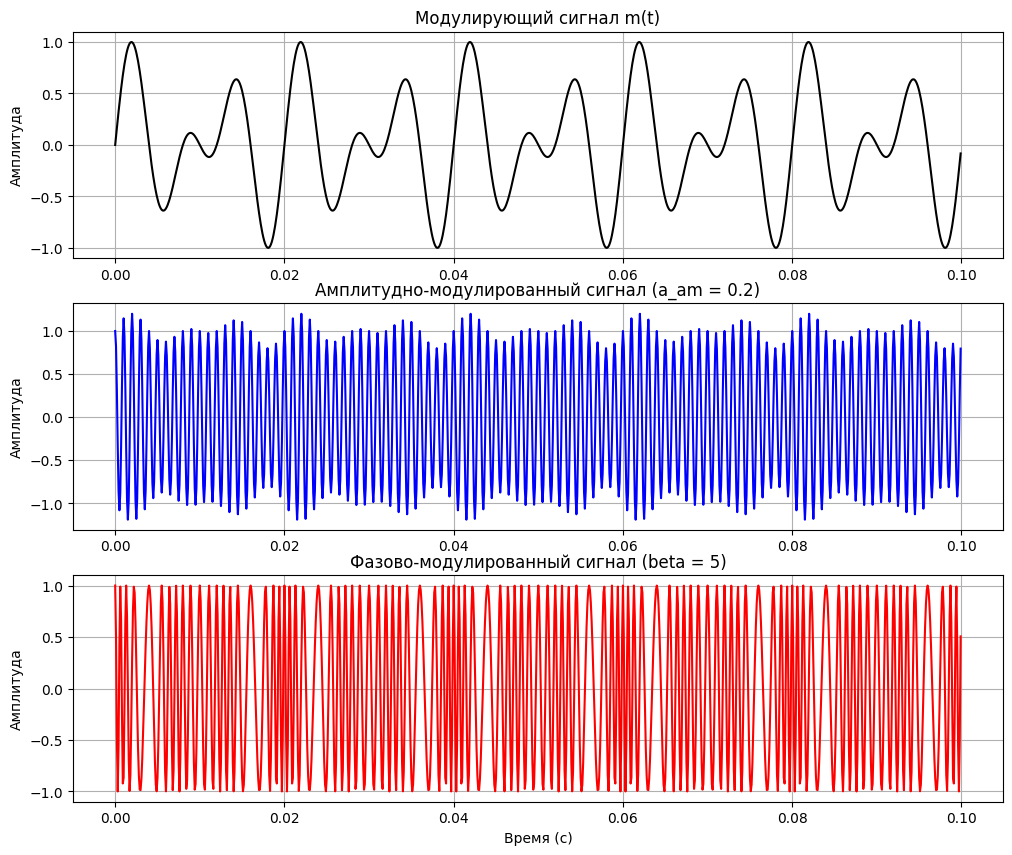

In [7]:
plt.figure(figsize=(12, 10))

# Модулирующий сигнал
plt.subplot(3, 1, 1)
plt.plot(t, m_t, color='black')
plt.title('Модулирующий сигнал m(t)')
plt.ylabel('Амплитуда')
plt.grid(True)

# АМ сигнал
plt.subplot(3, 1, 2)
plt.plot(t, s_am, color='blue')
plt.title(f'Амплитудно-модулированный сигнал (a_am = {a_am})')
plt.ylabel('Амплитуда')
plt.grid(True)

# ФМ сигнал
plt.subplot(3, 1, 3)
plt.plot(t, s_pm, color='red')
plt.title(f'Фазово-модулированный сигнал (beta = {beta_pm})')
plt.xlabel('Время (с)')
plt.ylabel('Амплитуда')
plt.grid(True)

plt.show()

## Часть 2. Спектральный анализ модулированных сигналов

### 2.1. Функция построения амплитудного спектра
Реализуйте функцию построения амплитудного спектра ```plot_spectrum(s,fs,title)```
Значения аргументов:
* `s` - массив, содержащий значения сигнала
* `fs` - частота отсчётов сигнала
* `title` - заголовок графика, выводимый сверху

На графике по горизонтальной оси должна быть отложена частота в герцах, а по вертикальной - амплитуда гармоники. График должен строиться только для положительных значений частоты. Оси должны быть подписаны.

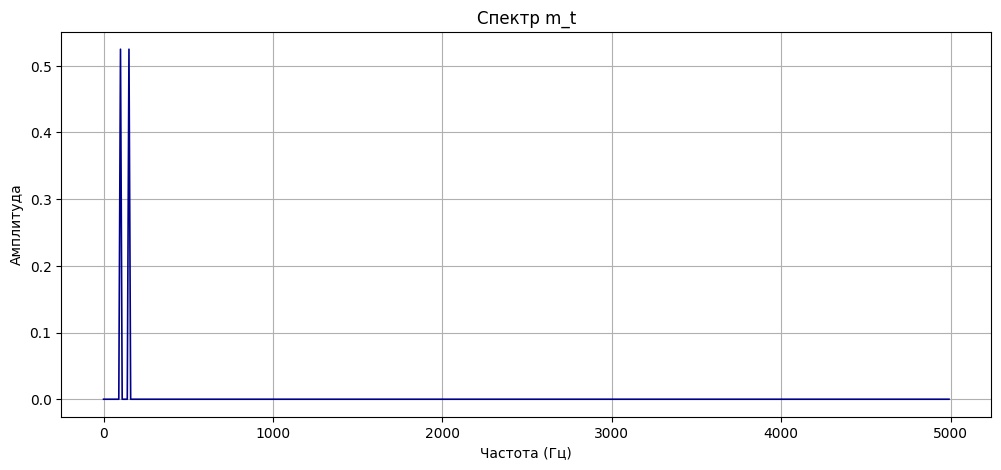

In [33]:
def plot_spectrum(s, fs, title):
  N = len(s)
  X = np.fft.fft(s)
  freq = np.fft.fftfreq(N, d=1/fs)

  half = N // 2
  freq_pos = freq[:half]
  # Нормируем амплитуды для получения корректных значений
  X_mag = (2.0 / N) * np.abs(X[:half])

  plt.plot(freq_pos, X_mag, color='darkblue', linewidth=1.2, linestyle='-')
  plt.title(title)
  plt.xlabel('Частота (Гц)')
  plt.ylabel('Амплитуда')
  plt.grid(True)
  plt.show()

plot_spectrum(m_t, fs, "Спектр m_t")

### 2.2. Спектр АМ

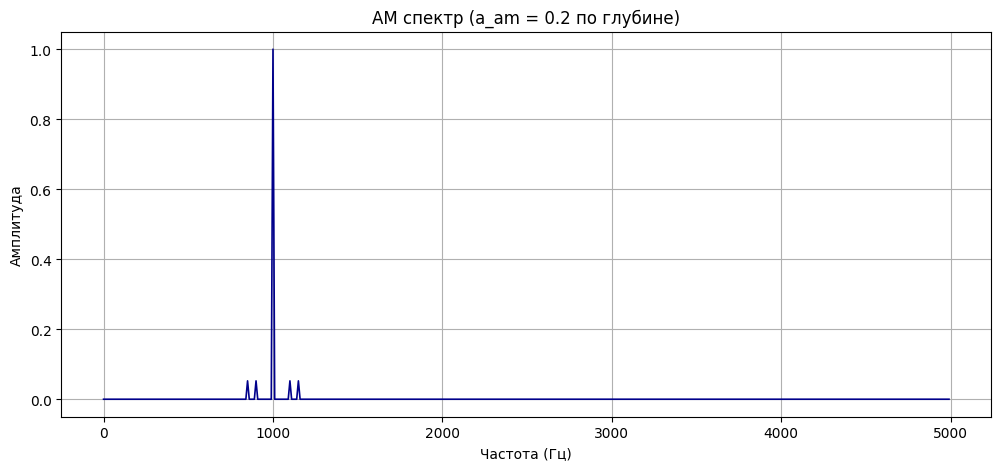

In [34]:
plot_spectrum(s_am, fs, f'АМ спектр (a_am = {a_am} по глубине)')

### 2.3. Спектр ФМ при разных индексах модуляции

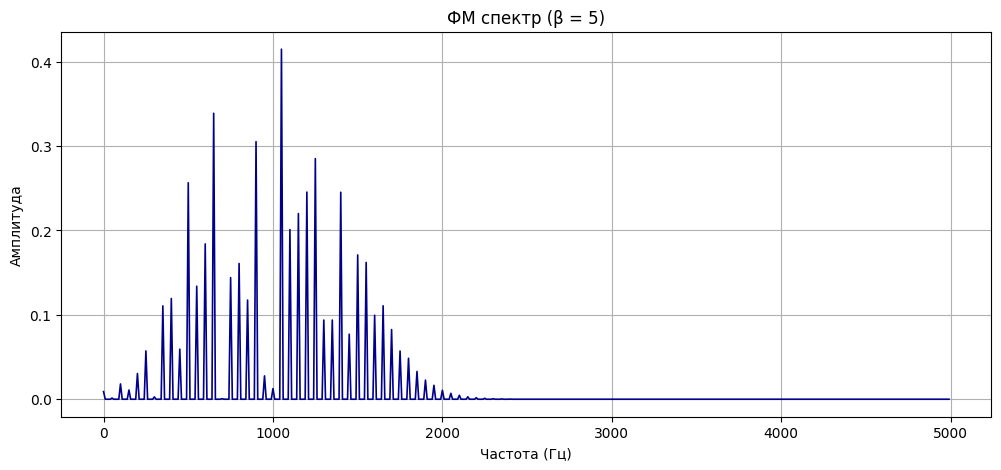

In [35]:
plot_spectrum(s_pm, fs, f'ФМ спектр (β = {beta_pm})')

Для ФМ постройте на одном графике спектры для разных индексов модуляции (например, β = 0.1, 0.3, 1, 2, 5, 10). Оси и графики должны быть подписаны.

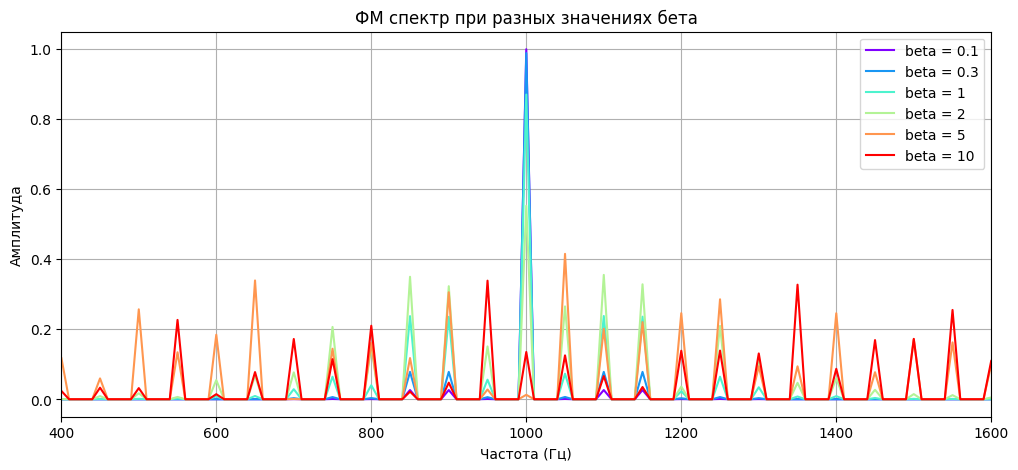

In [37]:
import matplotlib.cm as cm

def plot_fm_spectrum(beta_indexes, signals, fs, fc, name_plt):
  colors = cm.rainbow(np.linspace(0, 1, len(beta_indexes))) # Использование цветовой палитры
  for i, beta in enumerate(beta_indexes):
    s_pm = 1 * np.cos(2*np.pi*fc*t + beta * signals)
    N = len(s_pm)
    X = np.fft.fft(s_pm)
    freq = np.fft.fftfreq(N, d=1/fs)
    half = N // 2
    freq_pos = freq[:half]
    X_mag = (2.0 / N) * np.abs(X[:half])
    plt.plot(freq_pos, X_mag,  label=f'beta = {beta}', linewidth=1.5, color=colors[i]) # Применение цвета

  plt.title(name_plt)
  plt.xlabel('Частота (Гц)')
  plt.ylabel('Амплитуда')
  plt.grid(True)
  plt.legend()
  plt.xlim(fc -600, fc +600)
  plt.show()

# Индексы модуляции для ФМ
beta_indexes = [0.1, 0.3, 1, 2, 5, 10]
plot_fm_spectrum(beta_indexes, m_t, fs, fc, "ФМ спектр при разных значениях бета")

### 2.4. Интерактивное исследование спектра ФМ
Создайте интерактивный график для исследования зависимости спектра ФМ-сигнала от индекса модуляции.

In [38]:
from ipywidgets import interact, FloatSlider

def pm_spectrum(beta=5):
  s_pm = Ac * np.cos(2 * np.pi * fc * t + beta * m_t)
  plot_spectrum(s_pm, fs, f'ФМ спектр (beta = {beta})')

widgets.interact(pm_spectrum, beta=widgets.FloatSlider(min=0.1, max=20, step=0.1, value=5));

interactive(children=(FloatSlider(value=5.0, description='beta', max=20.0, min=0.1), Output()), _dom_classes=(…

**Вопросы:**
- Почему спектр АМ содержит только пять ярко выраженных компоненты (несущая и по две боковых с каждой стороны от неё)?
- Опишите, как выглядит спектр ФМ при малых β?
- Что происходит с амплитудой несущей и боковыми полосами ФМ при увеличении β?

**Ответы:**
- Потому что модулирующий сигнал состоит из двух синусоид (100 Гц и 150 Гц). Каждая из них создает пару боковых полос вокруг несущей, плюс сама несущая, что в сумме дает пять основных компонент: $f_c$, $f_c ± 100$ Гц и $f_c ± 150$ Гц.
- При малых значениях $\beta$ спектр ФМ очень похож на спектр АМ: он также содержит несущую и две пары боковых полос, близко расположенных к несущей. Амплитуды этих боковых полос пропорциональны $\beta$.
- При увеличении $\beta$ амплитуда несущей уменьшается (может даже стать нулевой), а спектр ФМ расширяется. Появляется больше боковых полос, и их амплитуды изменяются сложным образом, перераспределяя энергию от несущей к этим боковым полосам. Общая ширина спектра значительно увеличивается.

## Часть 3. Демодуляция сигналов

### 3.1. Демодуляция АМ с помощью преобразования Гильберта

Преобразование Гильберта позволяет получить аналитический сигнал, огибающая которого содержит исходное сообщение.

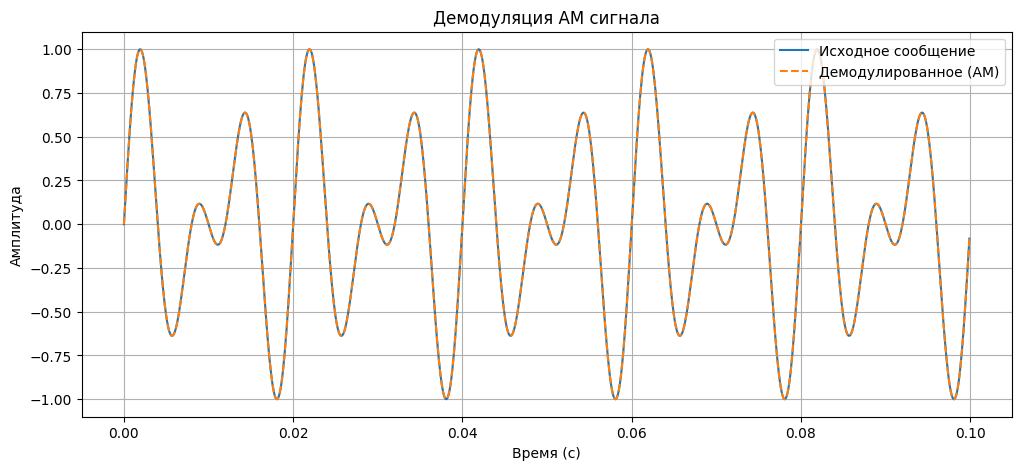

In [50]:
# Аналитический сигнал для АМ
analytic_am = hilbert(s_am)
envelope = np.abs(analytic_am) # огибающая = Ac * (1 + a_am * m(t))

# Убираем постоянную составляющую и нормализуем сигнал
demod_am = (envelope / Ac - 1) / a_am

# Сравнение с исходным
plt.figure()
plt.plot(t, m_t, label='Исходное сообщение')
plt.plot(t, demod_am, '--', label='Демодулированное (АМ)')
plt.xlabel('Время (с)')
plt.ylabel('Амплитуда')
plt.title('Демодуляция АМ сигнала')
plt.legend()
plt.grid(True)
plt.show()

Вычислите среднеквадратичную ошибку между исходным и восстановленным сообщением с помощью функции `np.std`.

In [51]:
mse = np.mean((m_t - demod_am)**2)
print(f'Среднеквадратичная ошибка (MSE) AM демодуляции: {mse:.4f}')

Среднеквадратичная ошибка (MSE) AM демодуляции: 0.0000


### 3.2. Демодуляция ФМ сигнала

Для ФМ информация заключена в отклонении фазы от линейного тренда. Используем аналитический сигнал и выделим мгновенную фазу.

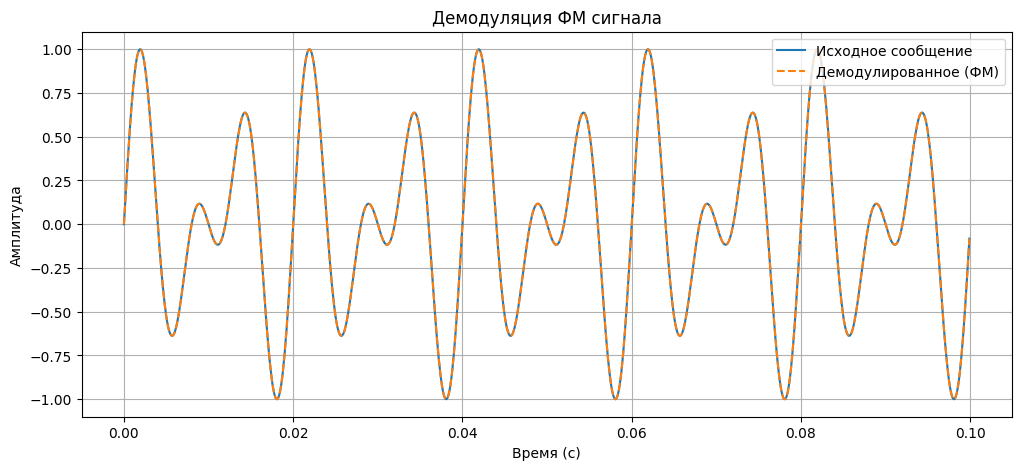

In [56]:
# Аналитический сигнал для ФМ
analytic_pm = hilbert(s_pm)
inst_phase = np.unwrap(np.angle(analytic_pm))   # развернутая фаза

# Убираем линейную составляющую (фаза несущей)
phase_no_carrier = inst_phase - 2 * np.pi * fc * t

# Убираем постоянную составляющую (может появиться в общем случае при наличии шумов, искажений и т. п.)
demod_pm = phase_no_carrier - np.mean(phase_no_carrier)

# Нормализуем сигнал
demod_pm = demod_pm / beta_pm

# Сравнение с исходным
plt.figure()
plt.plot(t, m_t, label='Исходное сообщение')
plt.plot(t, demod_pm, '--', label='Демодулированное (ФМ)')
plt.xlabel('Время (с)')
plt.ylabel('Амплитуда')
plt.title('Демодуляция ФМ сигнала')
plt.legend()
plt.grid(True)
plt.show()

**Вопрос:** Почему важно использовать `np.unwrap` для фазы?

**Ответ:** `np.unwrap` устраняет скачки фазы, делая ее непрерывной. Это нужно для точной демодуляции и правильных расчетов, избегая искажений.

## Часть 4. Устойчивость к шумам

В этой части мы работаем с реальным аудиофайлом. Для примера WAV-файл расположен в том же репозитории, что и ноутбук по адресу `data/sample-3s.wav`, но его надо загрузить в Google Colab.

### 4.1. Загрузка аудио (или генерация тестового сигнала)

In [55]:
# Загружаем файл и сохраняем под именем audio.wav
!wget -O audio.wav "https://github.com/korzhimanov/dsp-seminars/raw/refs/heads/main/data/sample-3s.wav"

--2026-04-06 20:39:08--  https://github.com/korzhimanov/dsp-seminars/raw/refs/heads/main/data/sample-3s.wav
Resolving github.com (github.com)... 140.82.116.3
Connecting to github.com (github.com)|140.82.116.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/korzhimanov/dsp-seminars/refs/heads/main/data/sample-3s.wav [following]
--2026-04-06 20:39:08--  https://raw.githubusercontent.com/korzhimanov/dsp-seminars/refs/heads/main/data/sample-3s.wav
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.109.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 563756 (551K) [audio/wav]
Saving to: ‘audio.wav’

audio.wav           100%[===================>] 550.54K  --.-KB/s    in 0.03s   

2026-04-06 20:39:09 (15.9 MB/s) - ‘audio.wav’ saved [563756/563756]



In [54]:
fs_audio, melody_stereo = wavfile.read('audio.wav') # читаем wav-файл в массив numpy, в файл записан стереосигнал, поэтому melody_stereo будет содержать две дорожки (левую и правую)

melody = melody_stereo[:,0] # переходим к моносигналу, беря только одну из двух дорожек
melody = melody / np.max(np.abs(melody)) # нормализуем сигнал, чтобы корректно работала амплитудная модуляция

t_audio = np.linspace(0, melody.shape[0]/fs_audio, melody.shape[0], endpoint=False) # для визуализации создаём также массив временных отсчётов

print(f"Частота дискретизации: {fs_audio} Гц")
print(f"Длина временного ряда: {len(melody)}")
print(f"Тип данных: {melody.dtype}")

print("Исходное аудио:")
display(Audio(melody, rate=fs_audio))

Частота дискретизации: 44100 Гц
Длина временного ряда: 140928
Тип данных: float64
Исходное аудио:


Постройте графики самого сигнала и его спектра. Подпишите оси.

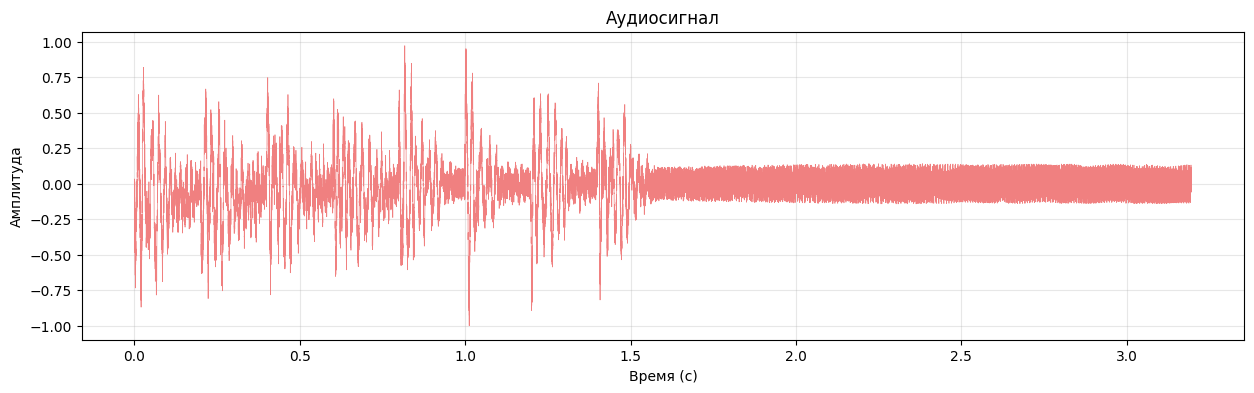

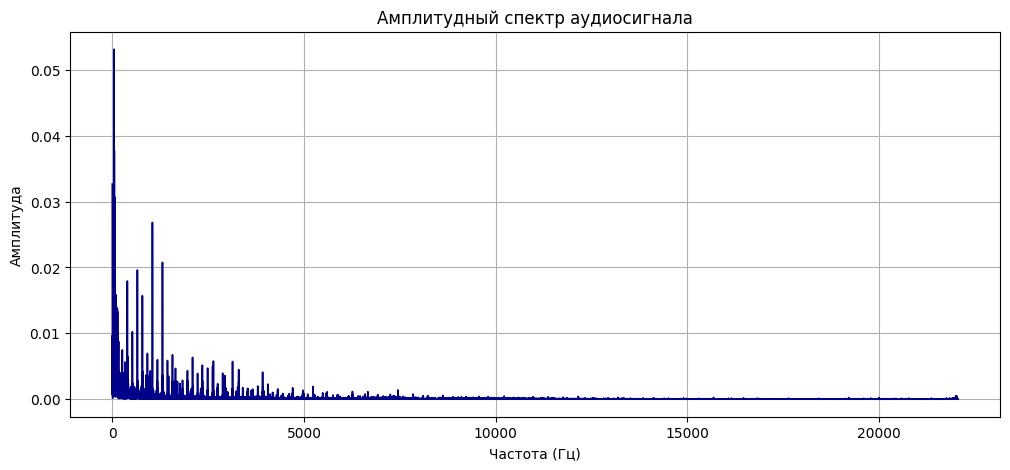

In [53]:
plt.figure(figsize=(15, 4))
plt.plot(t_audio, melody, color='lightcoral', linewidth=0.5)
plt.title('Аудиосигнал')
plt.xlabel('Время (с)')
plt.ylabel('Амплитуда')
plt.grid(True, alpha=0.3)
plt.show()

plot_spectrum(melody, fs_audio, "Амплитудный спектр аудиосигнала")

**Вопрос:** До каких частот наблюдаются заметные пики в сигнале? Подумайте, какую частоту несущей можно выбрать при частоте дискретизации 44,1 кГц, чтобы эти пики не потерять. Как на это влияет выбор индекса модуляции ФМ-сигнала?

**Ответ:** Заметные пики в аудиосигнале наблюдаются до 4-5 кГц. При частоте дискретизации 44.1 кГц можно выбрать несущую 5 кГц, чтобы спектр модулированного сигнала не выходил за пределы Найквиста (22.05 кГц). Выбор индекса модуляции $\beta$ для ФМ напрямую влияет на ширину спектра, так как слишком большое $\beta$ может расширить спектр так сильно, что это приведет к алиасингу и потере информации.

### 4.2. Подготовка к модуляции (интерполяция)

Выберите частоту несущей в соответствии с ответом на предыдущий вопрос (если восстановленный сигнал будет сильно зашумлён, попробуйте другие значения).

In [20]:
fc_high = 5000 # несущая 5 кГц
Ac = 1

### 4.3. Модуляция аудиосигнала
Сгенерируйте модулированные сигналы. Индекс модуляции для ФМ-сигнала выберите так, чтобы несильно портить модулируемый сигнал.

In [21]:
# АМ
a_am = 0.2
s_am_audio = Ac * (1 + a_am * melody) * np.cos(2 * np.pi * fc_high * t_audio)

# ФМ
beta_pm_audio = 2
s_pm_audio = Ac * np.cos(2 * np.pi * fc_high * t_audio + beta_pm_audio * melody)

### 4.4. Добавление шумов

**Амплитудный шум:** мультипликативный гауссов шум.

In [22]:
noise_amp = 0.1 * np.random.randn(len(t_audio))
s_am_noisy = s_am_audio * (1 + noise_amp)
s_pm_noisy = s_pm_audio * (1 + noise_amp)

### 4.5. Демодуляция сигналов

**Демодуляция АМ:**

Используйте преобразование Гильберта, чтобы демодулировать АМ-сигнал без шума, убедитесь, что качество звука изменилось незначительно.

In [27]:
envelope = np.abs(hilbert(s_am_audio))
m_recovered = (envelope / Ac - 1)/a_am

mse = np.std((melody - m_recovered)**2)

print(f'СКО: {mse:.6f}')
display(Audio(m_recovered, rate=fs_audio))

СКО: 0.005636


Демодулируйте зашумлёный АМ-сигнал.

In [28]:
envelope = np.abs(hilbert(s_am_noisy))
m_noisy_recovered = (envelope / Ac - 1)/a_am

mse = np.std((melody - m_noisy_recovered)**2)

print(f'СКО: {mse:.6f}')
display(Audio(m_noisy_recovered, rate=fs_audio))

СКО: 0.237592


**Вопросы:**
* Изменилось ли качество звука?
* Зафиксируйте $a_{AM}=0{,}2$. Попробуйте поменять амплитуду шума. При каких значениях амплитуды вы слышите заметную разницу с оригиналом?
* Зафиксируйте амплитуду шума равную 0,01. Попробуйте поменять $a_{AM}$, при каких амплитудах модуляции начинаются заметные искажения? Сделайте вывод о соотношении $a_{AM}$ и допустимых уровнях шума.

**Ответы:**
* Да, качество звука изменилось. Демодуляция чистого AM-сигнала имела минимальные изменения, но при наличии шума восстановленный сигнал был сильно зашумлен, что подтверждено увеличением MSE.
* При амплитуде шума около 0.05 мелодия различима, но сильно забита шумами. При 0.01 мелодия значительно чище, но фоновый шум заметен.
* При низких $a_{AM}$ (0.01-0.1) шум слышен отчетливее. Увеличение $a_{AM}$ до 0.5-1.0 делает искажения от шума менее заметными, так как полезный сигнал увеличивается. Вывод: более высокая глубина модуляции ($a_{AM}$) улучшает отношение сигнал/шум и устойчивость к помехам при фиксированном уровне шума.

**Демодуляция ФМ:**

Используйте метод аналитического сигнала для демодуляции ФМ-сигнала. Убедитесь, что качество звука изменилось незначительно.

In [29]:
analytic = hilbert(s_pm_audio)
instant_phase = np.unwrap(np.angle(analytic))
melody_restored = (instant_phase - 2 * np.pi * fc_high * t_audio) / beta_pm_audio

mse = np.mean((melody - melody_restored)**2)
print(f'MSE: {mse:.6f}')
display(Audio(melody_restored, rate=fs_audio))

MSE: 0.000083


Демодулируйте зашумлёный ФМ-сигнал.

In [30]:
analytic = hilbert(s_pm_noisy)
instant_phase = np.unwrap(np.angle(analytic))
melody_noisy_restored = (instant_phase - 2 * np.pi * fc_high * t_audio) / beta_pm_audio

mse = np.mean((melody - melody_noisy_restored)**2)
print(f'MSE: {mse:.6f}')
display(Audio(melody_noisy_restored, rate=fs_audio))

MSE: 0.001073


**Вопросы:**
* Изменилось ли качество звука?
* Зафиксируйте $\beta=2$. Попробуйте поменять амплитуду шума. При каких значениях амплитуды вы слышите заметную разницу с оригиналом?
* Зафиксируйте амплитуду шума равную 0,1. Попробуйте поменять $\beta$. Как субъективная величина искажений зависит от $\beta$?

**Ответы:**
*   Чистый ФМ-сигнал почти не меняет звук. С шумом качество падает, но ФМ держится лучше АМ.
*   Разница слышна при шуме 0.02-0.05. Выше — звук сильно портится.
*   Чем больше $\beta$, тем лучше ФМ-сигнал справляется с шумом, так как информация становится ярче, скажем так.

### 4.6. Сравнение спектров

Выберите значение амплитуды шума и величин $a_{AM}$ и $\beta$ так, чтобы искажения были заметны, но не велики. Постройте спектры исходного сигнала и сигналов, восстановлённых из зашумлённых АМ и ФМ-сигналов.

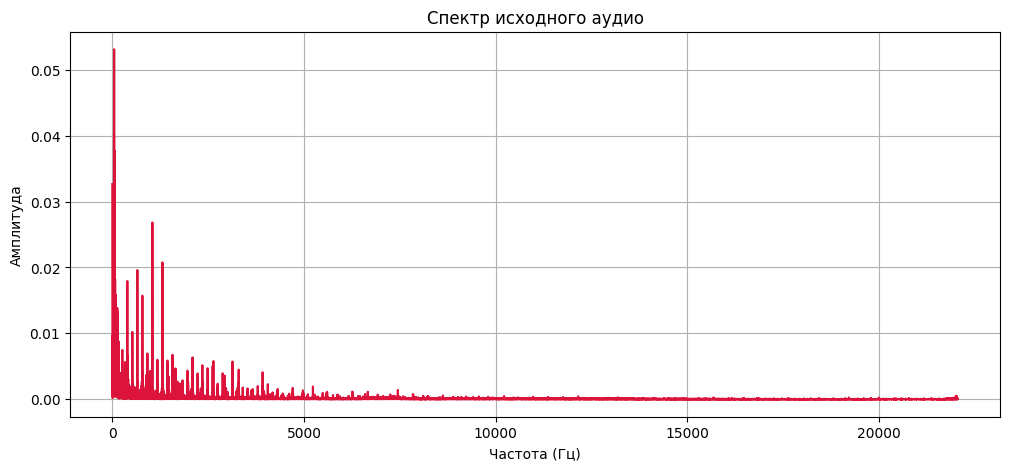

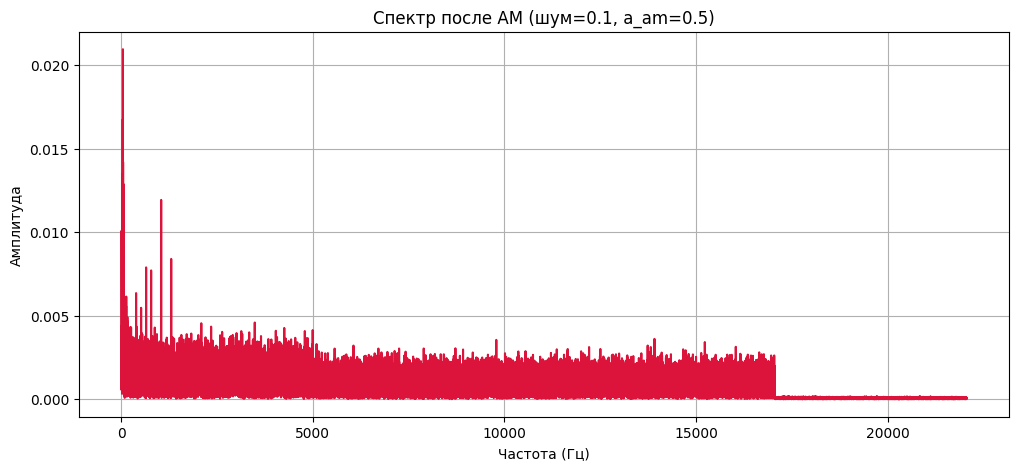

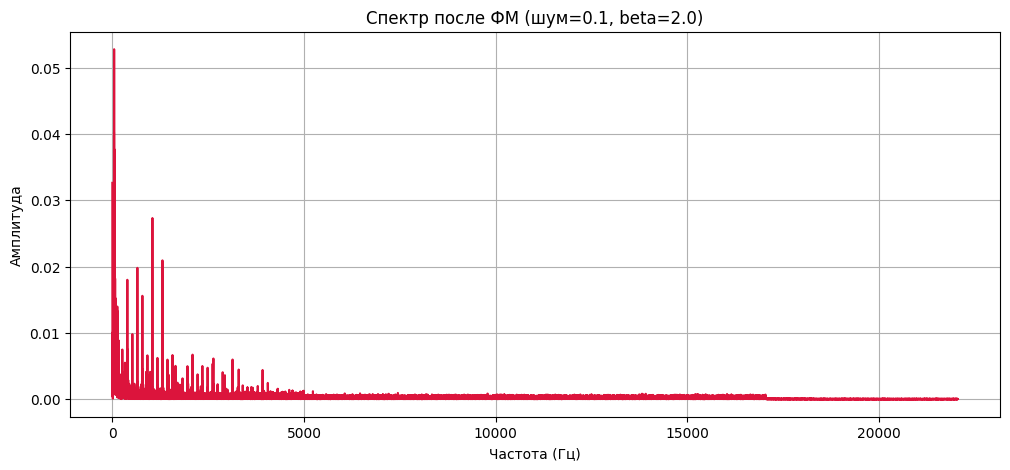

In [31]:
a_am_val = 0.5
beta_val = 2.0
noise_level = 0.1

noise = noise_level * np.random.randn(len(t_audio))

s_am_new_noisy = s_am_audio + noise
s_pm_new_noisy = s_pm_audio + noise

envelope = np.abs(hilbert(s_am_new_noisy))
m_noisy_recovered = (envelope / Ac - 1)/a_am_val

analytic = hilbert(s_pm_new_noisy)
instant_phase = np.unwrap(np.angle(analytic))
melody_noisy_restored = (instant_phase - 2 * np.pi * fc_high * t_audio) / beta_val

plot_spectrum(melody, fs_audio, 'Спектр исходного аудио')
plot_spectrum(m_noisy_recovered, fs_audio, f'Спектр после АМ (шум={noise_level}, a_am={a_am_val})')
plot_spectrum(melody_noisy_restored, fs_audio, f'Спектр после ФМ (шум={noise_level}, beta={beta_val})')

**Вопрос:**
* Заметны ли визуально искажения спектров для случаев АМ и ФМ?

**Ответ:**
Да, искажения спектров заметны визуально, но незначительно.

Постройте спектры АМ и ФМ сигналов. Зафиксируйте $\beta=2$, подберите $a_{AM}$ так, чтобы амплитуды гармоник в обоих случаях были сравнимы по величине.

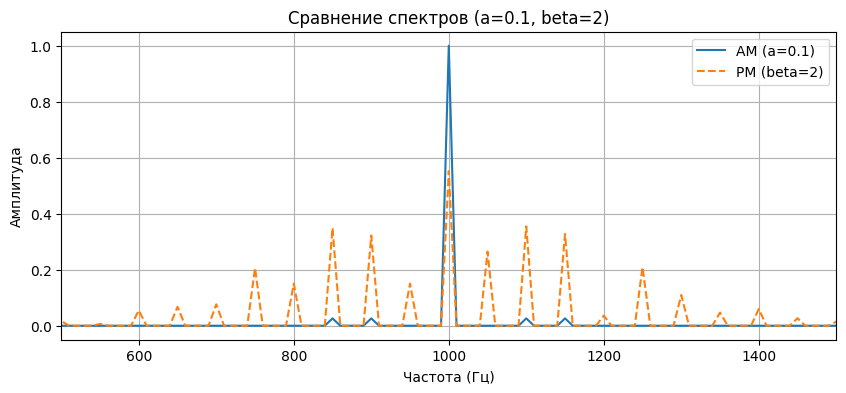

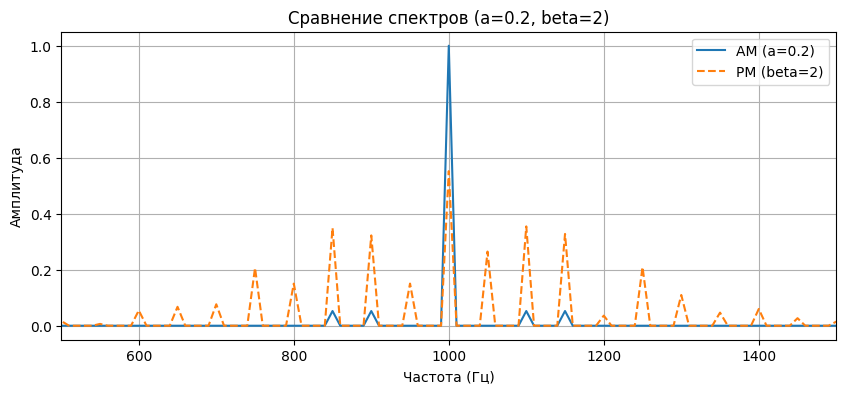

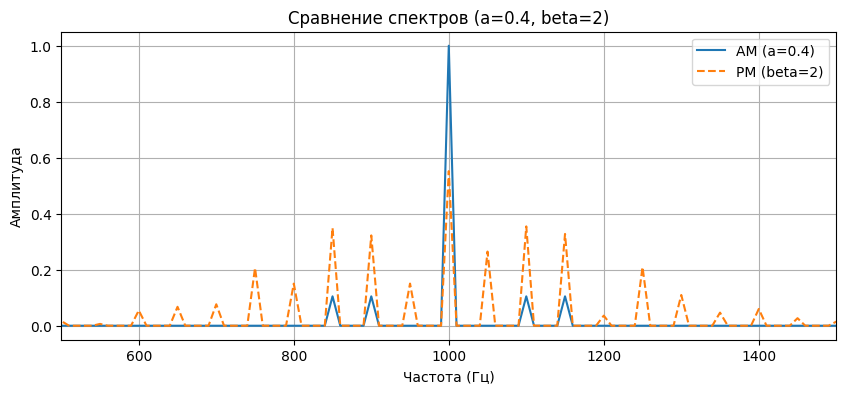

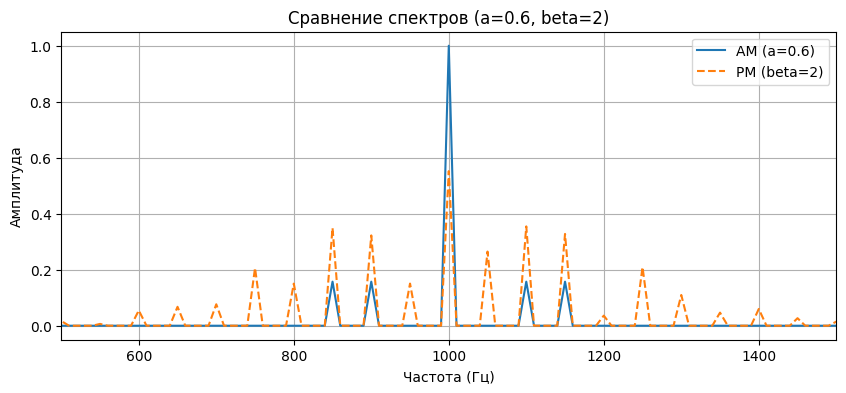

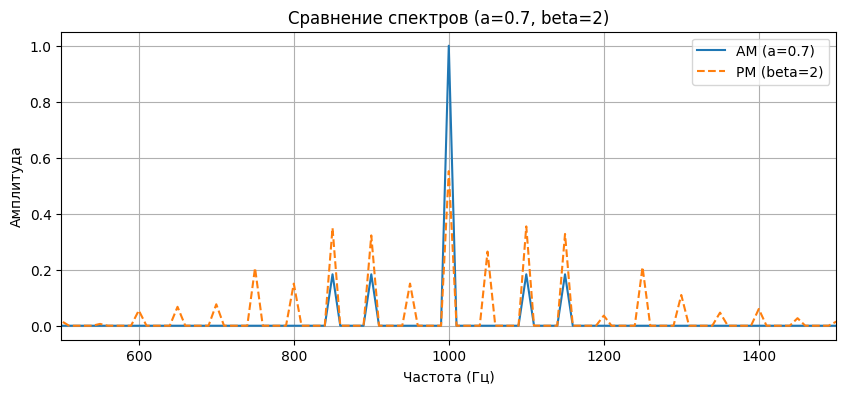

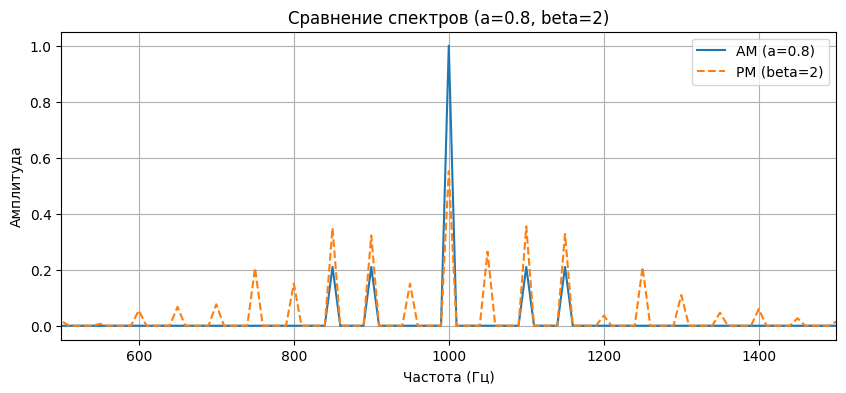

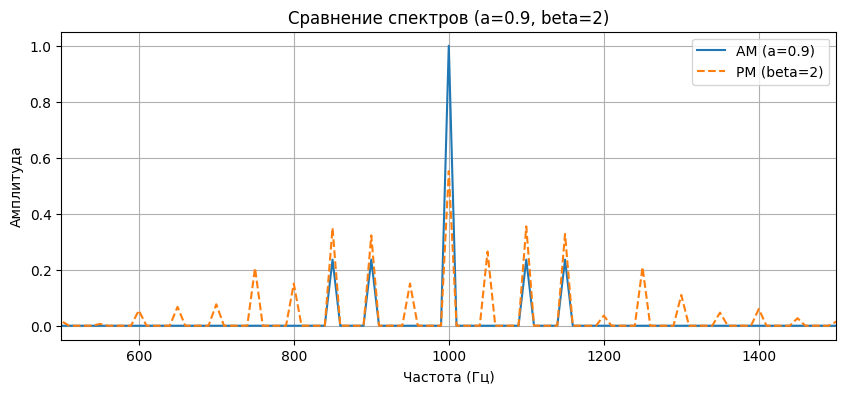

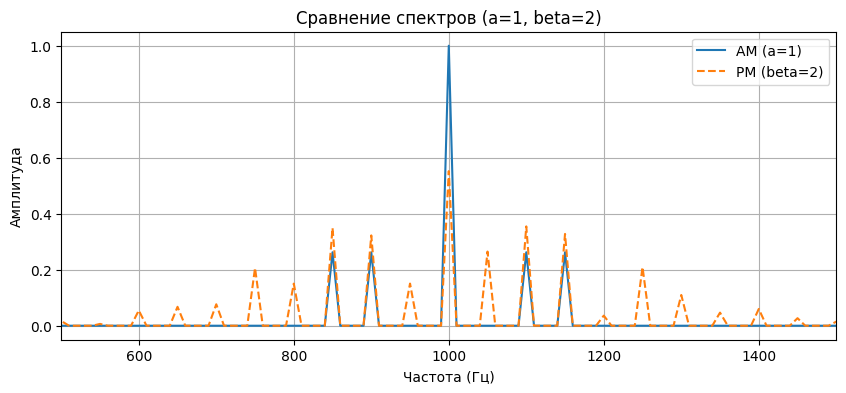

In [57]:
def compare_am_pm(a_values, beta, m_t, fc, t, fs, Ac):
    for a_am in a_values:
        # Используем глобально определенный Ac для консистентности
        s_am = Ac * (1 + a_am * m_t) * np.cos(2*np.pi*fc*t)
        s_pm = Ac * np.cos(2*np.pi*fc*t + beta * m_t)

        f_am, X_am = spectrum(s_am) # Используем глобальную функцию spectrum
        f_pm, X_pm = spectrum(s_pm) # Используем глобальную функцию spectrum

        plt.figure(figsize=(10,4))

        plt.plot(f_am, X_am, label=f'AM (a={a_am})')
        plt.plot(f_pm, X_pm, '--', label=f'PM (beta={beta})')

        plt.xlim(fc-500, fc+500)
        plt.xlabel('Частота (Гц)')
        plt.ylabel('Амплитуда')
        plt.title(f'Сравнение спектров (a={a_am}, beta={beta})')
        plt.legend()
        plt.grid(True)
        plt.show()

a_values = [0.1, 0.2, 0.4, 0.6, 0.7, 0.8, 0.9, 1]
beta = 2

# Передаем Ac в функцию
compare_am_pm(a_values, beta, m_t, fc, t, fs, Ac)

**Вопрос:**
* При какой амплитуде шума в этом случае вы слышите заметные искажения АМ сигнала? А ФМ сигнала? Сделайте вывод.

**Ответ:** При фиксированном $\beta=2$ и малых $a_{AM}$, искажения АМ-сигнала заметны даже при низком уровне шума. С увеличением $a_{AM}$ АМ-сигнал становится устойчивее, но всё равно чувствительнее ФМ. ФМ-сигнал при $\beta=2$ значительно устойчивее к шуму, чем АМ, и искажения появляются при более высоких уровнях шума.

**Вывод:** ФМ-модуляция более помехоустойчива, чем АМ, благодаря кодированию информации в фазе, а не в амплитуде, что делает её менее чувствительной к амплитудным шумам.